## Task Assignment

This notebook was completed by two team members working on the `Education` topic, with 5 analysis objectives as follows:

1. Identify ...
2. Identify ...
3. Identify ...
4. Identify ...
5. Identify ...

Based on that, we divided the work as follows:

| Student ID | Full Name | Task |
|------------|-----------|------|
| 23127130 | Nguyễn Hữu Anh Trí | Completed Objectives 1 to 3 |
| 23127238 | Trần Hoài Thiện Nhân | Completed Objectives 4 to 5 |


## I. Importing libraries


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

- Loading dataset


In [2]:
FOLDER_PATH = "dataset"
data = pd.read_csv(f"{FOLDER_PATH}/SoutheastAsianData.csv")


## II. Analyzing the Objectives


In [3]:
SEA_COUNTRIES = [
    "Brunei Darussalam",
    "Cambodia",
    "Indonesia",
    "Lao PDR",
    "Malaysia",
    "Myanmar",
    "Philippines",
    "Singapore",
    "Thailand",
    "Timor-Leste",
    "Viet Nam",
]


## Objective 1: Tracking trends in basic educational access through enrollment and out-of-school rates

### 1. Purpose:
The primary objective of this analysis is to directly measure the level of access to basic education over time. By pairing positive indicators (children in school) with negative indicators (children excluded from the system), this dual approach provides a much more comprehensive and compelling data narrative than relying on a single metric.

### 2. Question:

> How have the out-of-school rates for primary and lower-secondary school-age children changed over time? Does these trend differently depend on contries?


### 3. Choosing variables:

The selected variables are carefully paired to show the complete picture of basic educational access—both the "inclusion" (enrollment) and the "exclusion" (out-of-school) of students. 

- These negative metrics track the percentage of children who are currently slipping through the cracks of the education system:
    * **`Children out of school (% of primary school age)`**: The percentage of primary-school-age children who are not enrolled in any school.
    * **`Adolescents out of school (% of lower secondary school age)`**: The percentage of lower-secondary-school-age adolescents who are not enrolled in school.

- These positive metrics track the successful integration of children into the education system at the correct age:
    * **`School enrollment, primary (% net)`**: The percentage of official primary-school-age children who are enrolled in school.
    * **`School enrollment, secondary (% net)`**: The percentage of official secondary-school-age children who are enrolled in school.

In [4]:
OBJ1_COLS = {
    "primary_enroll": "School enrollment, primary (% net)",
    "primary_out": "Children out of school (% of primary school age)",
    "secondary_enroll": "School enrollment, secondary (% net)",
    "secondary_out": "Adolescents out of school (% of lower secondary school age)",
}

In [5]:
# Filling the missng values with the nearest year or between two nearest years

MISSING_VALUE_COLS = ['School enrollment, secondary (% net)']

for country in SEA_COUNTRIES:
    for var in MISSING_VALUE_COLS:
        country_data = data[data["Country Name"] == country][["Year", var]].copy()
        country_data["Year"] = pd.to_numeric(country_data["Year"], errors="coerce")
        country_data[var] = pd.to_numeric(country_data[var], errors="coerce")
        country_data.sort_values("Year", inplace=True)
        country_data[var] = country_data[var].interpolate(method="linear").ffill().bfill()
        data.loc[country_data.index, var] = country_data[var]

In [6]:
obj1_df = data.loc[data["Country Name"].isin(SEA_COUNTRIES), ["Country Name", "Year"] + list(OBJ1_COLS.values())].copy()
obj1_df["Year"] = pd.to_numeric(obj1_df["Year"], errors="coerce")

for col in OBJ1_COLS.values():
    obj1_df[col] = pd.to_numeric(obj1_df[col], errors="coerce")

obj1_df = obj1_df[obj1_df["Year"].between(2000, 2020)].copy()

obj1_yearly = obj1_df.groupby("Year", as_index=True)[list(OBJ1_COLS.values())].mean(numeric_only=True)


### 4. Chart selection

### A. Dual-Line Chart (or Panel Line Charts)
* **Purpose:** To visualize the inverse relationship between enrollment and out-of-school rates over time.
* **Rationale:** By plotting both the *net enrollment* (which should go up) and the *out-of-school rate* (which should go down) on the same timeline, the audience can clearly see the mirrored, inverse relationship. This visually proves whether drops in out-of-school populations perfectly translate into higher on-time enrollment.

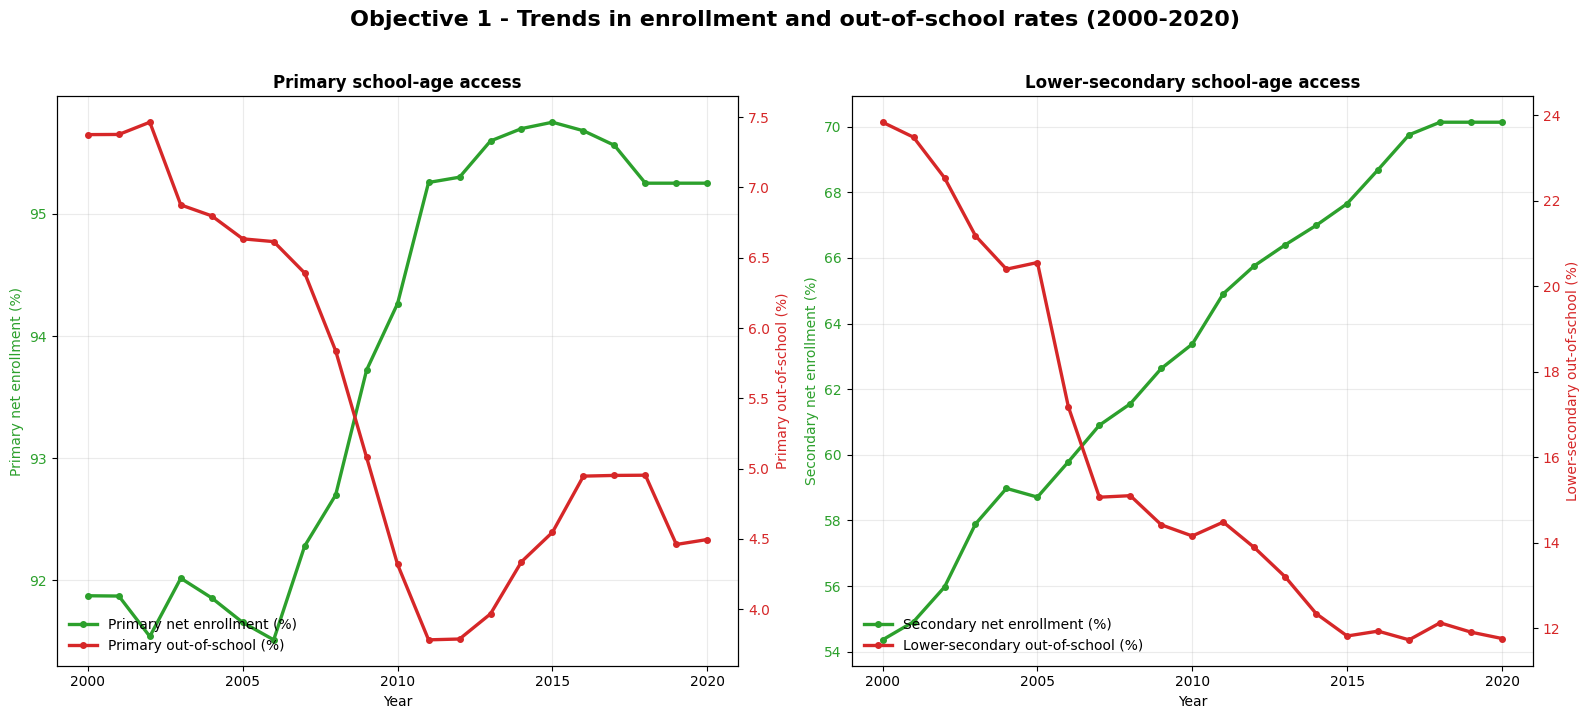

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

line_specs = [
    (
        "Primary school-age access",
        OBJ1_COLS["primary_enroll"],
        OBJ1_COLS["primary_out"],
        "Primary net enrollment (%)",
        "Primary out-of-school (%)",
    ),
    (
        "Lower-secondary school-age access",
        OBJ1_COLS["secondary_enroll"],
        OBJ1_COLS["secondary_out"],
        "Secondary net enrollment (%)",
        "Lower-secondary out-of-school (%)",
    ),
]

for ax, (title, enroll_col, out_col, enroll_label, out_label) in zip(axes, line_specs):
    ax.plot(
        obj1_yearly.index,
        obj1_yearly[enroll_col],
        color="#2ca02c",
        linewidth=2.4,
        marker="o",
        markersize=4,
        label=enroll_label,
    )
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel(enroll_label, color="#2ca02c")
    ax.tick_params(axis="y", labelcolor="#2ca02c")
    ax.grid(alpha=0.25)

    ax2 = ax.twinx()
    ax2.plot(
        obj1_yearly.index,
        obj1_yearly[out_col],
        color="#d62728",
        linewidth=2.4,
        marker="o",
        markersize=4,
        label=out_label,
    )
    ax2.set_ylabel(out_label, color="#d62728")
    ax2.tick_params(axis="y", labelcolor="#d62728")

    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower left", frameon=False)

for ax in axes:
    ax.set_xticks(range(2000, 2021, 5))

fig.suptitle(
    "Objective 1 - Trends in enrollment and out-of-school rates (2000-2020)",
    fontsize=16,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### Key observations:

- The charts show a clear inverse relationship between **enrollment rates** and **out-of-school rates** at both education levels.
- At the primary level, net enrollment rises gradually after 2007 and remains high after 2011, while the share of children out of school declines noticeably. This suggests that access to primary education improved over time.
- At the lower-secondary level, the pattern is even more obvious. Secondary net enrollment increases steadily from about 54% to around 70%, while the lower-secondary out-of-school rate falls sharply from nearly 24% to about 12%.

### Conclusion:

- Compared with primary education, secondary education shows a larger improvement, indicating that the region made stronger progress in expanding access at this level.
- Overall, the figure suggests that from 2000 to 2020, Southeast Asia experienced better educational access, reflected in rising enrollment and falling exclusion from school.

---



### B. Slope Chart
* **Purpose:** To compare how out-of-school rates changed between 2000 and 2020 across Southeast Asian countries.
* **Rationale:** A slope chart connects each country's starting value and ending value, making the direction and magnitude of change easy to compare. It is more suitable for country comparison than a multi-line time series because it reduces clutter and highlights which countries achieved the largest reductions in exclusion from school.


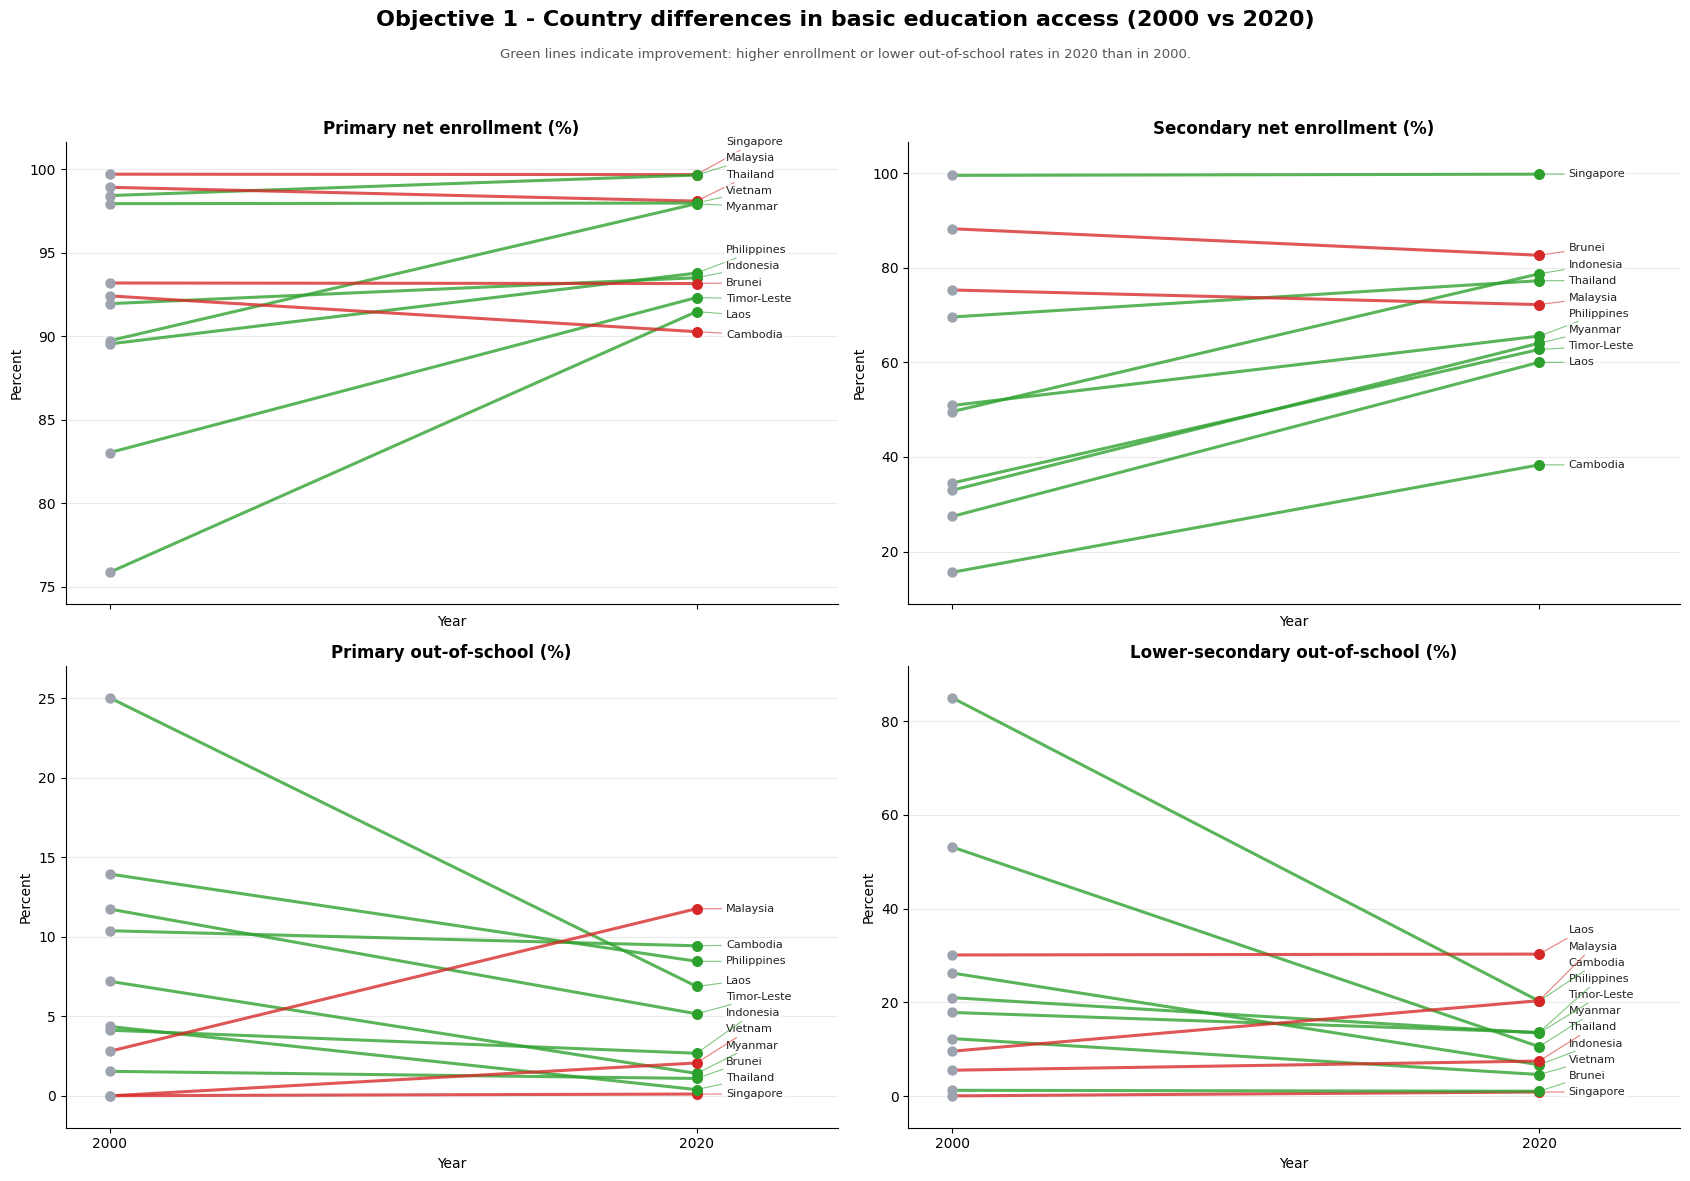

In [8]:
slope_specs = [
    {
        "key": "primary_enroll",
        "title": "Primary net enrollment (%)",
        "better": "up",
    },
    {
        "key": "secondary_enroll",
        "title": "Secondary net enrollment (%)",
        "better": "up",
    },
    {
        "key": "primary_out",
        "title": "Primary out-of-school (%)",
        "better": "down",
    },
    {
        "key": "secondary_out",
        "title": "Lower-secondary out-of-school (%)",
        "better": "down",
    },
]

label_map = {
    "Brunei Darussalam": "Brunei",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
}

slope_metric_cols = [OBJ1_COLS[spec["key"]] for spec in slope_specs]

slope_df = data.loc[
    data["Country Name"].isin(SEA_COUNTRIES),
    ["Country Name", "Year"] + slope_metric_cols,
].copy()

slope_df["Year"] = pd.to_numeric(slope_df["Year"], errors="coerce")

for col in slope_metric_cols:
    slope_df[col] = pd.to_numeric(slope_df[col], errors="coerce")

slope_df = slope_df[slope_df["Year"].isin([2000, 2020])].copy()

def make_slope_table(metric_col, better):
    table = (
        slope_df.pivot_table(index="Country Name", columns="Year", values=metric_col, aggfunc="mean")
        .dropna(subset=[2000, 2020])
        .reset_index()
    )
    sort_ascending = better == "down"
    return table.sort_values(2020, ascending=sort_ascending).reset_index(drop=True)

def spread_label_positions(values, lower, upper, min_gap):
    if len(values) == 0:
        return []

    order = np.argsort(values)
    sorted_vals = np.array(values, dtype=float)[order].copy()
    adjusted = sorted_vals.copy()

    adjusted[0] = max(adjusted[0], lower)
    for i in range(1, len(adjusted)):
        adjusted[i] = max(adjusted[i], adjusted[i - 1] + min_gap)

    overflow = adjusted[-1] - upper
    if overflow > 0:
        adjusted -= overflow

    adjusted[0] = max(adjusted[0], lower)
    for i in range(1, len(adjusted)):
        adjusted[i] = max(adjusted[i], adjusted[i - 1] + min_gap)

    if adjusted[-1] > upper:
        adjusted[-1] = upper
        for i in range(len(adjusted) - 2, -1, -1):
            adjusted[i] = min(adjusted[i], adjusted[i + 1] - min_gap)
        if adjusted[0] < lower:
            shift = lower - adjusted[0]
            adjusted += shift

    result = np.empty_like(adjusted)
    result[order] = adjusted
    return result.tolist()

fig, axes = plt.subplots(2, 2, figsize=(17, 12), sharex=True)
axes = axes.flatten()
fig.patch.set_facecolor("white")

for ax, spec in zip(axes, slope_specs):
    metric_col = OBJ1_COLS[spec["key"]]
    plot_df = make_slope_table(metric_col, spec["better"])

    y_min = min(plot_df[2000].min(), plot_df[2020].min())
    y_max = max(plot_df[2000].max(), plot_df[2020].max())
    y_pad = (y_max - y_min) * 0.08 if y_max > y_min else 1
    lower = y_min - y_pad
    upper = y_max + y_pad
    min_gap = max((upper - lower) * 0.035, 0.6)
    label_y_positions = spread_label_positions(plot_df[2020].tolist(), lower, upper, min_gap)

    for (_, row), label_y in zip(plot_df.iterrows(), label_y_positions):
        start = row[2000]
        end = row[2020]
        country = row["Country Name"]
        short_name = label_map.get(country, country)

        improved = (end >= start) if spec["better"] == "up" else (end <= start)
        line_color = "#2ca02c" if improved else "#d62728"

        ax.plot([2000, 2020], [start, end], color=line_color, linewidth=2.2, alpha=0.78)
        ax.scatter(2000, start, color="#9ca3af", s=42, zorder=3)
        ax.scatter(2020, end, color=line_color, s=48, zorder=3)

        ax.annotate(
            short_name,
            xy=(2020, end),
            xytext=(2021.0, label_y),
            textcoords="data",
            va="center",
            fontsize=8.1,
            color="#222222",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
            arrowprops=dict(arrowstyle="-", color=line_color, lw=0.8, alpha=0.6),
        )

    ax.set_title(spec["title"], fontsize=12, weight="bold")
    ax.set_xlim(1998.5, 2024.8)
    ax.set_ylim(lower, upper)
    ax.set_xticks([2000, 2020])
    ax.set_xlabel("Year")
    ax.set_ylabel("Percent")
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Objective 1 - Country differences in basic education access (2000 vs 2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

fig.text(
    0.5,
    0.94,
    "Green lines indicate improvement: higher enrollment or lower out-of-school rates in 2020 than in 2000.",
    ha="center",
    fontsize=9.5,
    color="#555555",
)

plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()


### Key observations

- Most countries improved between 2000 and 2020, shown by higher enrollment rates and lower out-of-school rates.
- At the **primary level**, several countries were already near universal enrollment in 2000, so the changes are relatively small.
- At the **secondary level**, improvements are much larger. Many countries show clear increases in net enrollment and strong declines in lower-secondary out-of-school rates.
- Some countries, such as **Singapore** and **Thailand**, remain among the strongest performers, while countries like **Cambodia**, **Lao PDR**, and **Timor-Leste** still have lower enrollment or higher exclusion compared with the regional leaders.
- A few countries show mixed results, where improvement is not equally strong across all indicators.

### Conclusion

- Overall, the charts show that basic education access improved across most Southeast Asian countries from 2000 to 2020.
- Progress is more noticeable at the secondary level than at the primary level.
- However, the differences between countries remain clear, meaning that educational access across the region is improving, but not yet fully equal.

---


## Objective 2: Government financial commitment and its relationship with educational access

### 1. Purpose:
The primary objective of this analysis is to evaluate how Southeast Asian nations prioritize education financially relative to their overall economic capacity. Furthermore, it aims to measure the "efficiency" of this investment by determining if higher government expenditure consistently correlates with increased primary and secondary school enrollment, or if some nations manage to achieve high access despite lower financial input.

### 2. Question:

> How do Southeast Asian countries differ in their financial prioritization of education (measured by GDP and total budget shares)? Does a higher financial commitment automatically translate to better primary and secondary educational access, or do some countries achieve "more with less"?

### 3. Choosing variables:

The selected variables contrast the **Financial Input** against the **Educational Outcome** to evaluate not just how much is spent, but how effectively that spending translates into getting children into classrooms.

- The "Investment": These metrics standardize government financial commitment for fair cross-country comparison:
    * **`Government expenditure on education, total (% of GDP)`**: Total public education spending expressed as a share of the national GDP.
    * **`Government expenditure on education, total (% of government expenditure)`**: Total public education spending expressed as a share of the overall government budget.

- The "Access": These indicators use both positive (enrollment) and negative (out-of-school) metrics to capture a complete picture of accessibility:
    * **`School enrollment, primary (% net)`**: The percentage of official primary-school-age children who are enrolled in school.
    * **`Children out of school (% of primary school age)`**: The percentage of primary-school-age children who are not enrolled in any school.
    * **`School enrollment, secondary (% net)`**: The percentage of official secondary-school-age children who are enrolled in school.
    * **`Adolescents out of school (% of lower secondary school age)`**: The percentage of lower-secondary-school-age adolescents who are not enrolled in school.


In [9]:
OBJ2_COLS = {
    "govt_gdp": "Government expenditure on education, total (% of GDP)",
    "govt_total": "Government expenditure on education, total (% of government expenditure)",
    "primary_enroll": "School enrollment, primary (% net)",
    "primary_out": "Children out of school (% of primary school age)",
    "secondary_enroll": "School enrollment, secondary (% net)",
    "secondary_out": "Adolescents out of school (% of lower secondary school age)",
}

In [10]:
sns.set_theme(style="whitegrid", context="notebook")

label_map = {
    "Brunei Darussalam": "Brunei",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
}

obj2_df = data.loc[
    data["Country Name"].isin(SEA_COUNTRIES),
    ["Country Name", "Year"] + list(OBJ2_COLS.values()),
].copy()

obj2_df["Year"] = pd.to_numeric(obj2_df["Year"], errors="coerce")

for col in OBJ2_COLS.values():
    obj2_df[col] = pd.to_numeric(obj2_df[col], errors="coerce")

obj2_df = obj2_df[obj2_df["Year"].between(2000, 2020)].copy()
obj2_df["Country Label"] = obj2_df["Country Name"].replace(label_map)


## 4. Chart selection

### A. Correlation Heatmap
* **Purpose:** To visualize the strength of the relationship between the government's financial investment and the resulting educational access.
* **Rationale:** A heatmap is a highly efficient way to display a correlation matrix. By plotting the financial input variables against the educational outcome variables, and using color saturation to represent how strongly they are linked (e.g., dark shades for strong correlations), the audience can instantly pre-attentively process whether spending actually drives enrollment, without getting lost in messy data points.


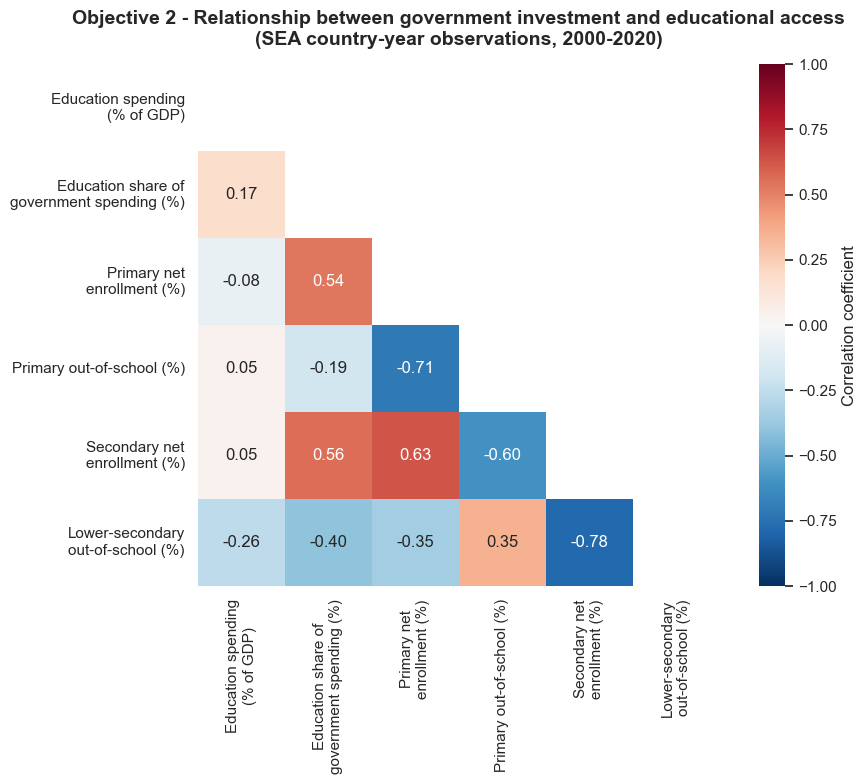

In [11]:
# Chart A: Correlation heatmap between government investment and educational access

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="white", context="notebook")

heat_cols = [
    OBJ2_COLS["govt_gdp"],
    OBJ2_COLS["govt_total"],
    OBJ2_COLS["primary_enroll"],
    OBJ2_COLS["primary_out"],
    OBJ2_COLS["secondary_enroll"],
    OBJ2_COLS["secondary_out"],
]

obj2_heat_df = data.loc[
    data["Country Name"].isin(SEA_COUNTRIES),
    ["Country Name", "Year"] + heat_cols,
].copy()

obj2_heat_df["Year"] = pd.to_numeric(obj2_heat_df["Year"], errors="coerce")

for col in heat_cols:
    obj2_heat_df[col] = pd.to_numeric(obj2_heat_df[col], errors="coerce")

obj2_heat_df = obj2_heat_df[obj2_heat_df["Year"].between(2000, 2020)].copy()

corr_df = obj2_heat_df[heat_cols].corr(method="pearson")

label_map = {
    OBJ2_COLS["govt_gdp"]: "Education spending\n(% of GDP)",
    OBJ2_COLS["govt_total"]: "Education share of\ngovernment spending (%)",
    OBJ2_COLS["primary_enroll"]: "Primary net\nenrollment (%)",
    OBJ2_COLS["primary_out"]: "Primary out-of-school (%)",
    OBJ2_COLS["secondary_enroll"]: "Secondary net\nenrollment (%)",
    OBJ2_COLS["secondary_out"]: "Lower-secondary\nout-of-school (%)",
}

corr_df = corr_df.rename(index=label_map, columns=label_map)

mask = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(False)

sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0,
    cbar_kws={"label": "Correlation coefficient"},
    ax=ax,
)

ax.set_title(
    "Objective 2 - Relationship between government investment and educational access\n"
    "(SEA country-year observations, 2000-2020)",
    fontsize=14,
    weight="bold",
    pad=14,
)

ax.set_facecolor("white")

plt.tight_layout()
plt.show()


### Key observations

- The strongest relationship appears between **primary net enrollment** and **primary out-of-school rates** (`-0.71`), and between **secondary net enrollment** and **lower-secondary out-of-school rates** (`-0.78`). This confirms the expected inverse relationship between inclusion and exclusion.
- **Education spending as a share of government expenditure** shows a moderate positive correlation with both **primary enrollment** (`0.54`) and **secondary enrollment** (`0.56`).
- The same spending indicator is negatively correlated with **lower-secondary out-of-school rates** (`-0.40`), suggesting that stronger budget prioritization of education is generally associated with better access.
- In contrast, **education spending as a share of GDP** has only very weak correlations with most access indicators. This suggests that spending relative to GDP alone does not strongly explain differences in enrollment or exclusion.
- Enrollment at the primary and secondary levels is also positively related (`0.63`), meaning countries with better access at one level tend to perform better at the other level as well.

### Conclusion

- Overall, the heatmap suggests that **government budget priority for education** is more closely related to educational access than **education spending as a share of GDP**.
- Better access is reflected in **higher enrollment** and **lower out-of-school rates**, especially at the secondary level.
- Therefore, the results imply that simply spending more relative to GDP may not be enough; what seems to matter more is how strongly education is prioritized within total government spending.

---


# Objective 3: Gender disparity in educational access across different levels of education

## 1. Purpose:
The primary objective of this analysis is to evaluate gender inequalities in educational access across primary, secondary, and tertiary levels. This analysis is highly relevant to the theme of gender equality, aiming to identify where the gender gap is most pronounced and whether parity achieved at foundational levels is maintained or lost in higher education.

## 2. Question:

> At which educational level (primary, secondary, or tertiary) does the gender gap appear the strongest? Are there specific countries that achieve gender parity at foundational levels but experience significant disparities at higher education levels?

## 3. Choosing variables:

The selected variables focus specifically on comparing male and female participation rates across the three main tiers of the education system, alongside the standardized Gender Parity Index (GPI) to explicitly measure inequality.
### Enrollment rates by gender
These metrics compare the actual enrollment percentages of males and females at each educational level:
* **`School enrollment, primary, female/male (% net)`**: The percentage of official primary-school-age children enrolled in primary school, broken down by gender.
* **`School enrollment, secondary, female/male (% net)`**: The percentage of official secondary-school-age children enrolled in secondary school, broken down by gender.
* **`School enrollment, tertiary, female/male (% gross)`**: The ratio of total tertiary enrollment to the population of the corresponding official age group, broken down by gender. *(Note: Tertiary education typically uses gross rather than net rates due to age variability).*

### Gender Parity Index (GPI)
These indicators directly measure the ratio of female to male enrollment. A GPI of 1 indicates perfect equality; less than 1 indicates a disparity in favor of males, and greater than 1 indicates a disparity in favor of females.
* **`School enrollment, primary (gross), gender parity index (GPI)`**: The gender parity index for primary education.
* **`School enrollment, secondary (gross), gender parity index (GPI)`**: The gender parity index for secondary education.
* **`School enrollment, tertiary (gross), gender parity index (GPI)`**: The gender parity index for tertiary education.


In [ ]:
SELECTED_YEARS = [2000, 2020]

OBJ3_COLS = {
    "primary_female": "School enrollment, primary, female (% net)",
    "primary_male": "School enrollment, primary, male (% net)",
    "secondary_female": "School enrollment, secondary, female (% net)",
    "secondary_male": "School enrollment, secondary, male (% net)",
    "tertiary_female": "School enrollment, tertiary, female (% gross)",
    "tertiary_male": "School enrollment, tertiary, male (% gross)",
    "primary_gpi": "School enrollment, primary (gross), gender parity index (GPI)",
    "secondary_gpi": "School enrollment, secondary (gross), gender parity index (GPI)",
    "tertiary_gpi": "School enrollment, tertiary (gross), gender parity index (GPI)",
}

obj3_df = data[data["Country Name"].isin(SEA_COUNTRIES)].copy()
obj3_df["Year"] = pd.to_numeric(obj3_df["Year"], errors="coerce")

for col in OBJ3_COLS.values():
    obj3_df[col] = pd.to_numeric(obj3_df[col], errors="coerce")

display_names = {
    "Brunei Darussalam": "Brunei",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
}
country_order = [display_names.get(country, country) for country in SEA_COUNTRIES]

obj3_selected = obj3_df.loc[
    obj3_df["Year"].isin(SELECTED_YEARS),
    ["Country Name", "Year"] + list(OBJ3_COLS.values()),
].copy()

obj3_selected["Country"] = obj3_selected["Country Name"].replace(display_names)
obj3_selected["Country"] = pd.Categorical(
    obj3_selected["Country"],
    categories=country_order,
    ordered=True,
)

In [22]:
# Find if any columns have mising values
missing_cols = [col for col in OBJ2_COLS.values() if obj2_selected[col].isna().any()]
print("Columns with missing values:", missing_cols)

Columns with missing values: ['School enrollment, primary, female (% net)', 'School enrollment, primary, male (% net)', 'School enrollment, secondary, female (% net)', 'School enrollment, secondary, male (% net)', 'School enrollment, secondary (gross), gender parity index (GPI)']


## 4. Chart selection

### A. Dumbbell Plot
* **Purpose:** To visualize the absolute enrollment gap between males and females at different education levels for a specific year.
* **Rationale:** A dumbbell plot is the most effective chart for highlighting the distance (gap) between two data points. By placing the male percentage and female percentage on the same horizontal axis connected by a line, the exact size of the gender disparity becomes immediately obvious for each country.

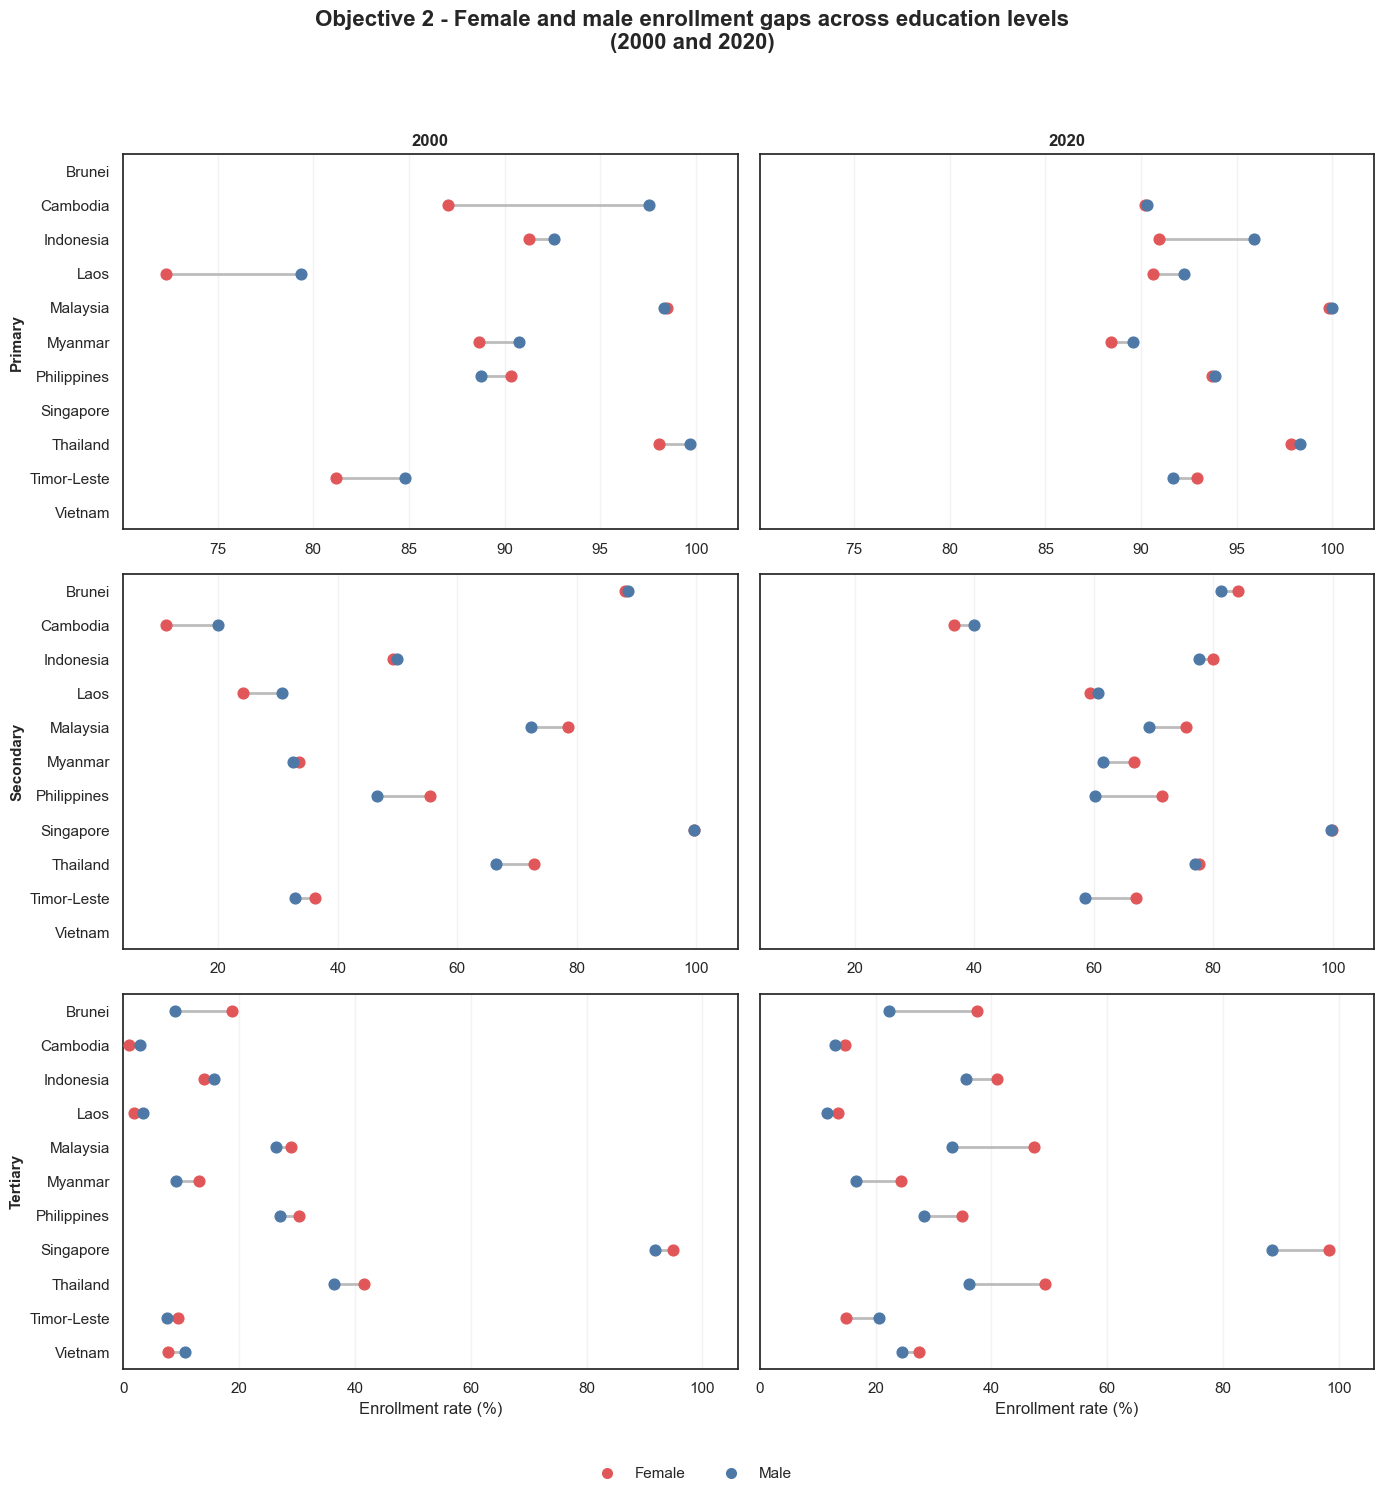

In [ ]:
# Chart 1: Dumbbell plots for female-male enrollment gaps across 2000 and 2020
dumbbell_specs = [
    (
        OBJ3_COLS["primary_female"],
        OBJ3_COLS["primary_male"],
        "Primary",
    ),
    (
        OBJ3_COLS["secondary_female"],
        OBJ3_COLS["secondary_male"],
        "Secondary",
    ),
    (
        OBJ3_COLS["tertiary_female"],
        OBJ3_COLS["tertiary_male"],
        "Tertiary",
    ),
]

female_color = "#E15759"
male_color = "#4E79A7"

x_limits = {}
for female_col, male_col, _ in dumbbell_specs:
    vals = pd.concat(
        [obj2_selected[female_col], obj2_selected[male_col]],
        ignore_index=True,
    ).dropna()
    x_min = vals.min()
    x_max = vals.max()
    x_pad = (x_max - x_min) * 0.08 if x_max > x_min else 2
    x_limits[(female_col, male_col)] = (max(0, x_min - x_pad), x_max + x_pad)

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.patch.set_facecolor("white")

for row, (female_col, male_col, level_name) in enumerate(dumbbell_specs):
    x_left, x_right = x_limits[(female_col, male_col)]

    for col, year in enumerate(SELECTED_YEARS):
        ax = axes[row, col]

        plot_df = obj2_selected.loc[
            obj2_selected["Year"].eq(year),
            ["Country", female_col, male_col],
        ].dropna().copy()

        plot_df = plot_df.sort_values("Country")
        plot_df["y"] = plot_df["Country"].cat.codes

        ax.hlines(
            y=plot_df["y"],
            xmin=plot_df[female_col],
            xmax=plot_df[male_col],
            color="#B5B5B5",
            linewidth=2,
            alpha=0.9,
        )
        ax.scatter(plot_df[female_col], plot_df["y"], color=female_color, s=60, zorder=3)
        ax.scatter(plot_df[male_col], plot_df["y"], color=male_color, s=60, zorder=3)

        ax.set_xlim(x_left, x_right)
        ax.set_ylim(-0.5, len(country_order) - 0.5)
        ax.invert_yaxis()

        if row == 0:
            ax.set_title(str(year), fontsize=12, weight="bold")

        if col == 0:
            ax.set_ylabel(level_name, fontsize=11, weight="bold")
            ax.set_yticks(range(len(country_order)))
            ax.set_yticklabels(country_order)
        else:
            ax.set_ylabel("")
            ax.set_yticks(range(len(country_order)))
            ax.set_yticklabels([])

        if row == 2:
            ax.set_xlabel("Enrollment rate (%)")

        ax.grid(axis="x", alpha=0.25)
        ax.set_axisbelow(True)

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=female_color, markersize=9, label="Female"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=male_color, markersize=9, label="Male"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    "Objective 3 - Female and male enrollment gaps across education levels\n(2000 and 2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()


### B. Grouped Bar Chart
* **Purpose:** To compare the Gender Parity Index (GPI) across primary, secondary, and tertiary levels side-by-side for each country.
* **Rationale:** By grouping three bars (Primary GPI, Secondary GPI, Tertiary GPI) together for each country and adding a baseline reference line at 1.0 (perfect parity), the audience can easily spot transitions. It perfectly answers the question of whether a country achieves balance at a lower level but skews heavily at a higher level.

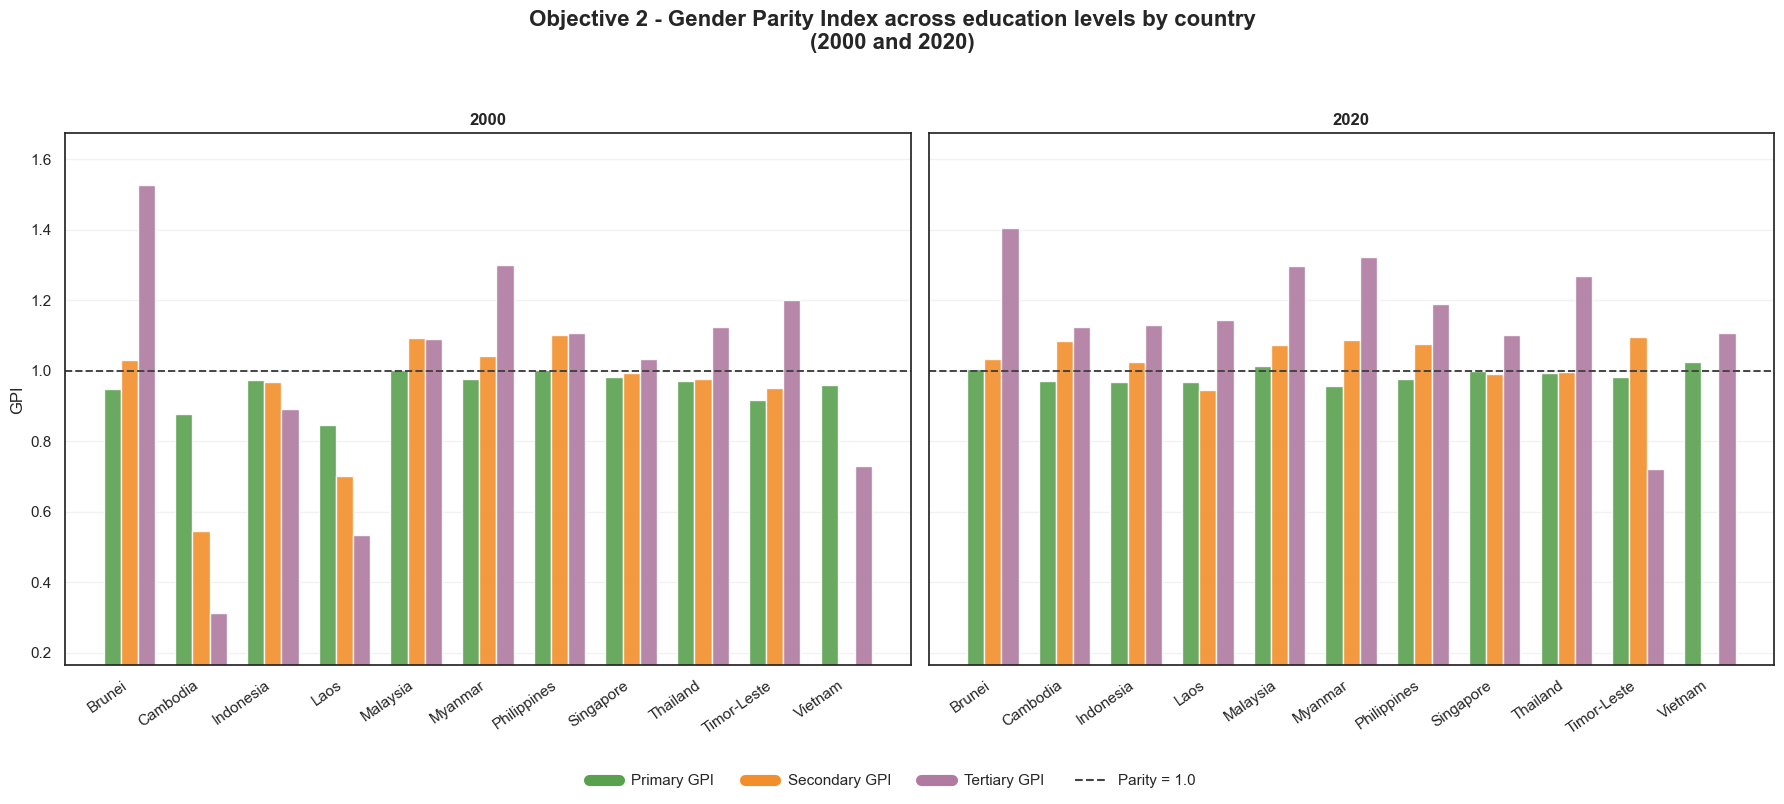

In [ ]:
# Chart 2: Grouped bar charts for GPI across 2000 and 2020

gpi_specs = [
    (OBJ3_COLS["primary_gpi"], "Primary GPI", "#59A14F"),
    (OBJ3_COLS["secondary_gpi"], "Secondary GPI", "#F28E2B"),
    (OBJ3_COLS["tertiary_gpi"], "Tertiary GPI", "#B07AA1"),
]

gpi_values = obj2_selected[[spec[0] for spec in gpi_specs]].to_numpy(dtype=float)
gpi_min = np.nanmin(gpi_values)
gpi_max = np.nanmax(gpi_values)
gpi_pad = (gpi_max - gpi_min) * 0.12 if gpi_max > gpi_min else 0.1

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
width = 0.24

for ax, year in zip(axes, SELECTED_YEARS):
    gpi_df = obj2_selected.loc[
        obj2_selected["Year"].eq(year),
        ["Country"] + [spec[0] for spec in gpi_specs],
    ].copy()

    gpi_df["Country"] = pd.Categorical(gpi_df["Country"], categories=country_order, ordered=True)
    gpi_df = gpi_df.sort_values("Country")

    x = np.arange(len(gpi_df))

    for i, (col, label, color) in enumerate(gpi_specs):
        ax.bar(
            x + (i - 1) * width,
            gpi_df[col],
            width=width,
            label=label,
            color=color,
            alpha=0.9,
        )

    ax.axhline(1.0, color="#444444", linestyle="--", linewidth=1.4)
    ax.set_ylim(max(0, gpi_min - gpi_pad), gpi_max + gpi_pad)
    ax.set_title(str(year), fontsize=12, weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(gpi_df["Country"], rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

axes[0].set_ylabel("GPI")

legend_handles = [
    Line2D([0], [0], color="#59A14F", lw=8, label="Primary GPI"),
    Line2D([0], [0], color="#F28E2B", lw=8, label="Secondary GPI"),
    Line2D([0], [0], color="#B07AA1", lw=8, label="Tertiary GPI"),
    Line2D([0], [0], color="#444444", lw=1.5, linestyle="--", label="Parity = 1.0"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    "Objective 3 - Gender Parity Index across education levels by country\n(2000 and 2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

plt.tight_layout(rect=(0, 0.05, 1, 0.95))
plt.show()


# Objective 4: Monitoring youth literacy rates and gender disparities in foundational learning outcomes

## 1. Purpose:
The primary objective of this analysis is to evaluate youth literacy (ages 15-24) as a foundational learning outcome. Replacing the less feasible "learning poverty" metric for the 2000–2020 timeframe, this objective bridges the gap between mere educational access (getting kids into school) and actual educational quality (ensuring they can read and write). It also aims to track gender parity in these foundational skills.

## 2. Question:

> How have youth (ages 15-24) literacy rates evolved across Southeast Asian countries? Furthermore, do countries with high levels of educational access (secondary and tertiary enrollment) consistently demonstrate correspondingly high youth literacy rates?

## 3. Choosing variables:

The selected variables are divided into two categories: measuring the actual learning outcome (literacy and gender parity) and measuring the access level to see if one translates to the other. 

### Youth literacy and gender parity
These metrics measure the foundational reading and writing capabilities of the youth population and whether there is a gender divide in these skills:
* **`Literacy rate, youth total (% of people ages 15-24)`**: The percentage of people ages 15-24 who can both read and write with understanding a short simple statement about their everyday life, broken down by total, female, and male.
* **`Literacy rate, youth (ages 15-24), gender parity index (GPI)`**: The ratio of the female youth literacy rate to the male youth literacy rate. A value of 1 indicates perfect equality.

### Educational access indicators (For correlation)
These variables are included to test whether higher school enrollment guarantees higher literacy:
* **`School enrollment, secondary (% net)`**: The percentage of official secondary-school-age children who are actually enrolled in secondary school.
* **`School enrollment, tertiary (% gross)`**: The ratio of total tertiary enrollment to the population of the corresponding official age group.


In [16]:
OBJ4_COLS = {
    "youth_total": "Literacy rate, youth total (% of people ages 15-24)",
    "youth_gpi": "Literacy rate, youth (ages 15-24), gender parity index (GPI)",
    "secondary_net": "School enrollment, secondary (% net)",
    "tertiary_gross": "School enrollment, tertiary (% gross)",
}

obj4_df = data[data["Country Name"].isin(SEA_COUNTRIES)].copy()
obj4_df["Year"] = pd.to_numeric(obj4_df["Year"], errors="coerce")

for col in OBJ4_COLS.values():
    obj4_df[col] = pd.to_numeric(obj4_df[col], errors="coerce")

obj4_df = obj4_df[obj4_df["Year"].between(2000, 2020)].copy()

obj4_display_names = {
    "Brunei Darussalam": "Brunei",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
}
obj4_country_order = [obj4_display_names.get(country, country) for country in SEA_COUNTRIES]
obj4_df["Country"] = obj4_df["Country Name"].replace(obj4_display_names)

obj4_palette = dict(
    zip(obj4_country_order, sns.color_palette("tab20", n_colors=len(obj4_country_order)))
)

## 4. Chart selection

### A. Scatterplot 
* **Purpose:** To visualize the correlation between educational access (e.g., secondary enrollment) and foundational learning (youth literacy rate).
* **Rationale:** A standard scatterplot is perfect for showing the relationship between two different variables. By putting Secondary Enrollment on the X-axis and Youth Literacy Rate on the Y-axis, you can immediately see if countries that get more kids into school also successfully teach them to read (which would show as dots clustering in the top-right quadrant).

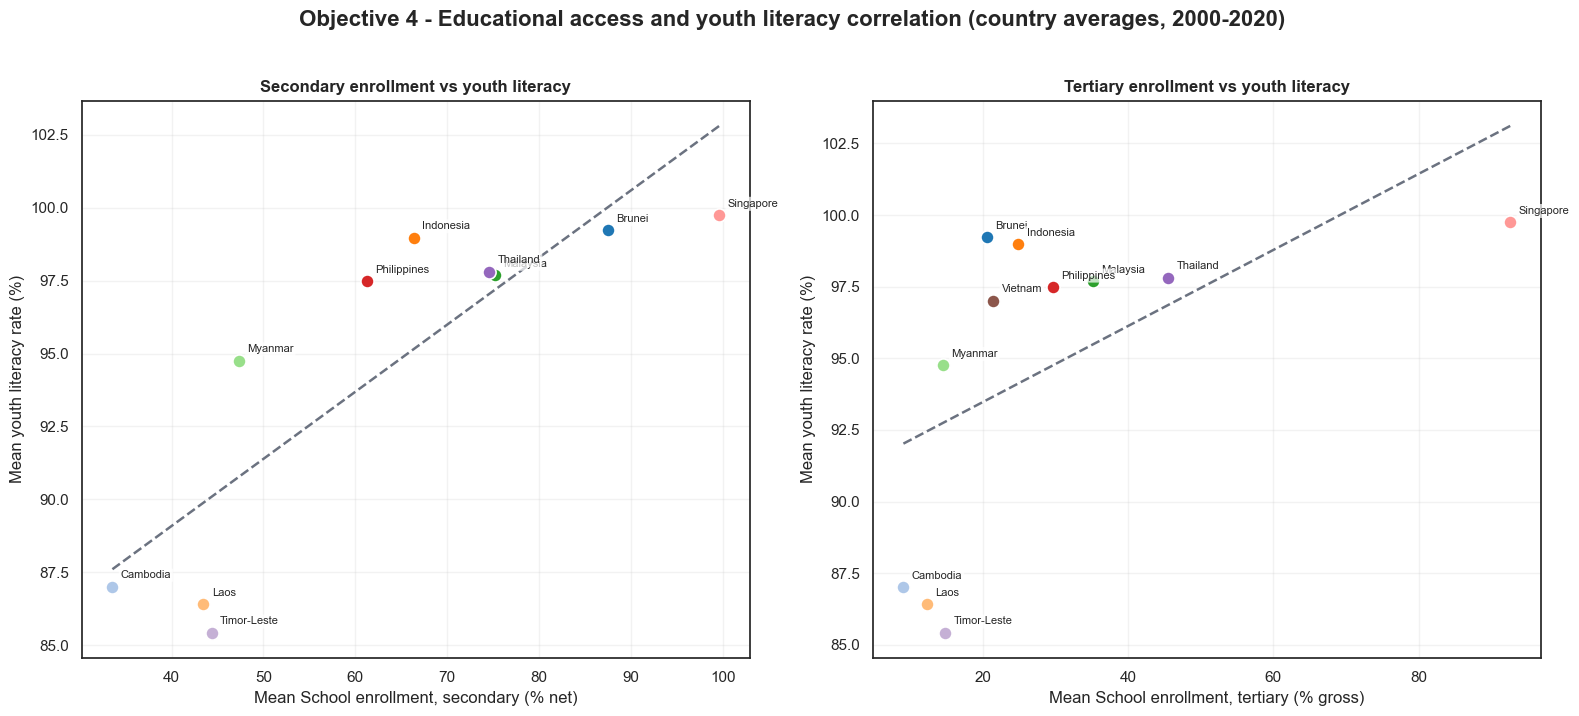

In [18]:
# Chart 2: Scatterplots for educational access and youth literacy
obj4_corr = (
    obj4_df.groupby("Country", as_index=False)[
        [OBJ4_COLS["secondary_net"], OBJ4_COLS["tertiary_gross"], OBJ4_COLS["youth_total"]]
    ]
    .mean(numeric_only=True)
)

scatter_specs = [
    (OBJ4_COLS["secondary_net"], "Secondary enrollment vs youth literacy"),
    (OBJ4_COLS["tertiary_gross"], "Tertiary enrollment vs youth literacy"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (x_col, title) in zip(axes, scatter_specs):
    plot_df = obj4_corr[["Country", x_col, OBJ4_COLS["youth_total"]]].dropna().copy()

    sns.regplot(
        data=plot_df,
        x=x_col,
        y=OBJ4_COLS["youth_total"],
        scatter=False,
        ci=None,
        line_kws={"color": "#6B7280", "linestyle": "--", "linewidth": 1.8},
        ax=ax,
    )

    for _, row in plot_df.iterrows():
        country = row["Country"]
        ax.scatter(
            row[x_col],
            row[OBJ4_COLS["youth_total"]],
            s=90,
            color=obj4_palette[country],
            edgecolor="white",
            linewidth=1.2,
            zorder=3,
        )
        ax.annotate(
            country,
            (row[x_col], row[OBJ4_COLS["youth_total"]]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.72),
        )

    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel(f"Mean {x_col}")
    ax.set_ylabel("Mean youth literacy rate (%)")
    ax.grid(alpha=0.25)

fig.suptitle(
    "Objective 4 - Educational access and youth literacy correlation (country averages, 2000-2020)",
    fontsize=16,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()


## Objective 5: Long-term educational attainment and gender disparities among the adult population

### 1. Purpose:
The primary objective of this analysis is to evaluate the long-term educational achievements of the adult population (aged 25 and older) across different countries. Specifically, it aims to assess the overall level of education completed and to identify any existing gender disparities at advanced academic levels (Bachelor's, Master's, and Doctoral degrees), providing a clear snapshot of human capital and educational equity.

### 2. Question:

> How does the overall educational attainment of the adult population (aged 25+) differ across countries? Furthermore, is the gender gap consistent across higher education levels, such as Bachelor's, Master's, and Doctoral degrees?

#### Chosing variables:

The selected variables focus exclusively on the cumulative educational outcomes of the adult population. They are categorized by the highest level of education completed and include gender-specific breakdowns to allow for disparity analysis.

#### Baseline educational attainment
These variables establish the foundation of basic and secondary education within the adult population.
* **`Educational attainment, at least completed primary, population 25+ years, total (%)`**: The percentage of the population aged 25 and over that has successfully completed at least primary education.
* **`Educational attainment, at least completed upper secondary, population 25+, total (%)`**: The percentage of the population aged 25 and over that has successfully completed at least upper secondary education.

#### Higher education and gender parity
These variables measure advanced academic achievements and must be analyzed using their **total, female, and male** variants to evaluate inequality at higher tiers of learning.
* **`Educational attainment, at least Bachelor's or equivalent, population 25+, total/female/male (%)`**: The percentage of the adult population that has attained at least a Bachelor's degree or equivalent.
* **`Educational attainment, at least Master's or equivalent, population 25+, total/female/male (%)`**: The percentage of the adult population that has attained at least a Master's degree or equivalent.
* **`Educational attainment, Doctoral or equivalent, population 25+, total/female/male (%)`**: The percentage of the adult population that has attained a Doctoral degree or equivalent.


In [19]:
SELECTED_YEARS = [2000, 2020]

OBJ5_COLS = {
    "primary_total": "Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative)",
    "upper_secondary_total": "Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative)",
    "bachelor_total": "Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative)",
    "bachelor_female": "Educational attainment, at least Bachelor's or equivalent, population 25+, female (%) (cumulative)",
    "bachelor_male": "Educational attainment, at least Bachelor's or equivalent, population 25+, male (%) (cumulative)",
    "master_total": "Educational attainment, at least Master's or equivalent, population 25+, total (%) (cumulative)",
    "master_female": "Educational attainment, at least Master's or equivalent, population 25+, female (%) (cumulative)",
    "master_male": "Educational attainment, at least Master's or equivalent, population 25+, male (%) (cumulative)",
    "doctoral_total": "Educational attainment, Doctoral or equivalent, population 25+, total (%) (cumulative)",
    "doctoral_female": "Educational attainment, Doctoral or equivalent, population 25+, female (%) (cumulative)",
    "doctoral_male": "Educational attainment, Doctoral or equivalent, population 25+, male (%) (cumulative)",
}

obj5_df = data[data["Country Name"].isin(SEA_COUNTRIES)].copy()
obj5_df["Year"] = pd.to_numeric(obj5_df["Year"], errors="coerce")

for col in OBJ5_COLS.values():
    obj5_df[col] = pd.to_numeric(obj5_df[col], errors="coerce")

display_names = {
    "Brunei Darussalam": "Brunei",
    "Lao PDR": "Laos",
    "Viet Nam": "Vietnam",
}
country_order = [display_names.get(country, country) for country in SEA_COUNTRIES]

obj5_selected = obj5_df.loc[
    obj5_df["Year"].isin(SELECTED_YEARS),
    ["Country Name", "Year"] + list(OBJ5_COLS.values()),
].copy()

obj5_selected["Country"] = obj5_selected["Country Name"].replace(display_names)
obj5_selected["Country"] = pd.Categorical(
    obj5_selected["Country"],
    categories=country_order,
    ordered=True,
)

## 4. Chart selection

Because this objective focuses on comparing absolute achievements and disparities rather than tracking continuous changes over a long period, the data is best suited for a specific year snapshot (e.g., 2020) rather than a dense time-series chart.

### A. Horizontal Bar Chart
* **Purpose:** To compare the overall educational attainment levels across different countries in a specific snapshot year.
* **Rationale:** Bar charts are highly effective for comparing categorical data (different countries) against numerical values (percentages). Sorting the bars from highest to lowest makes it incredibly easy for the audience to rank countries by their proportion of educated adults at a glance.

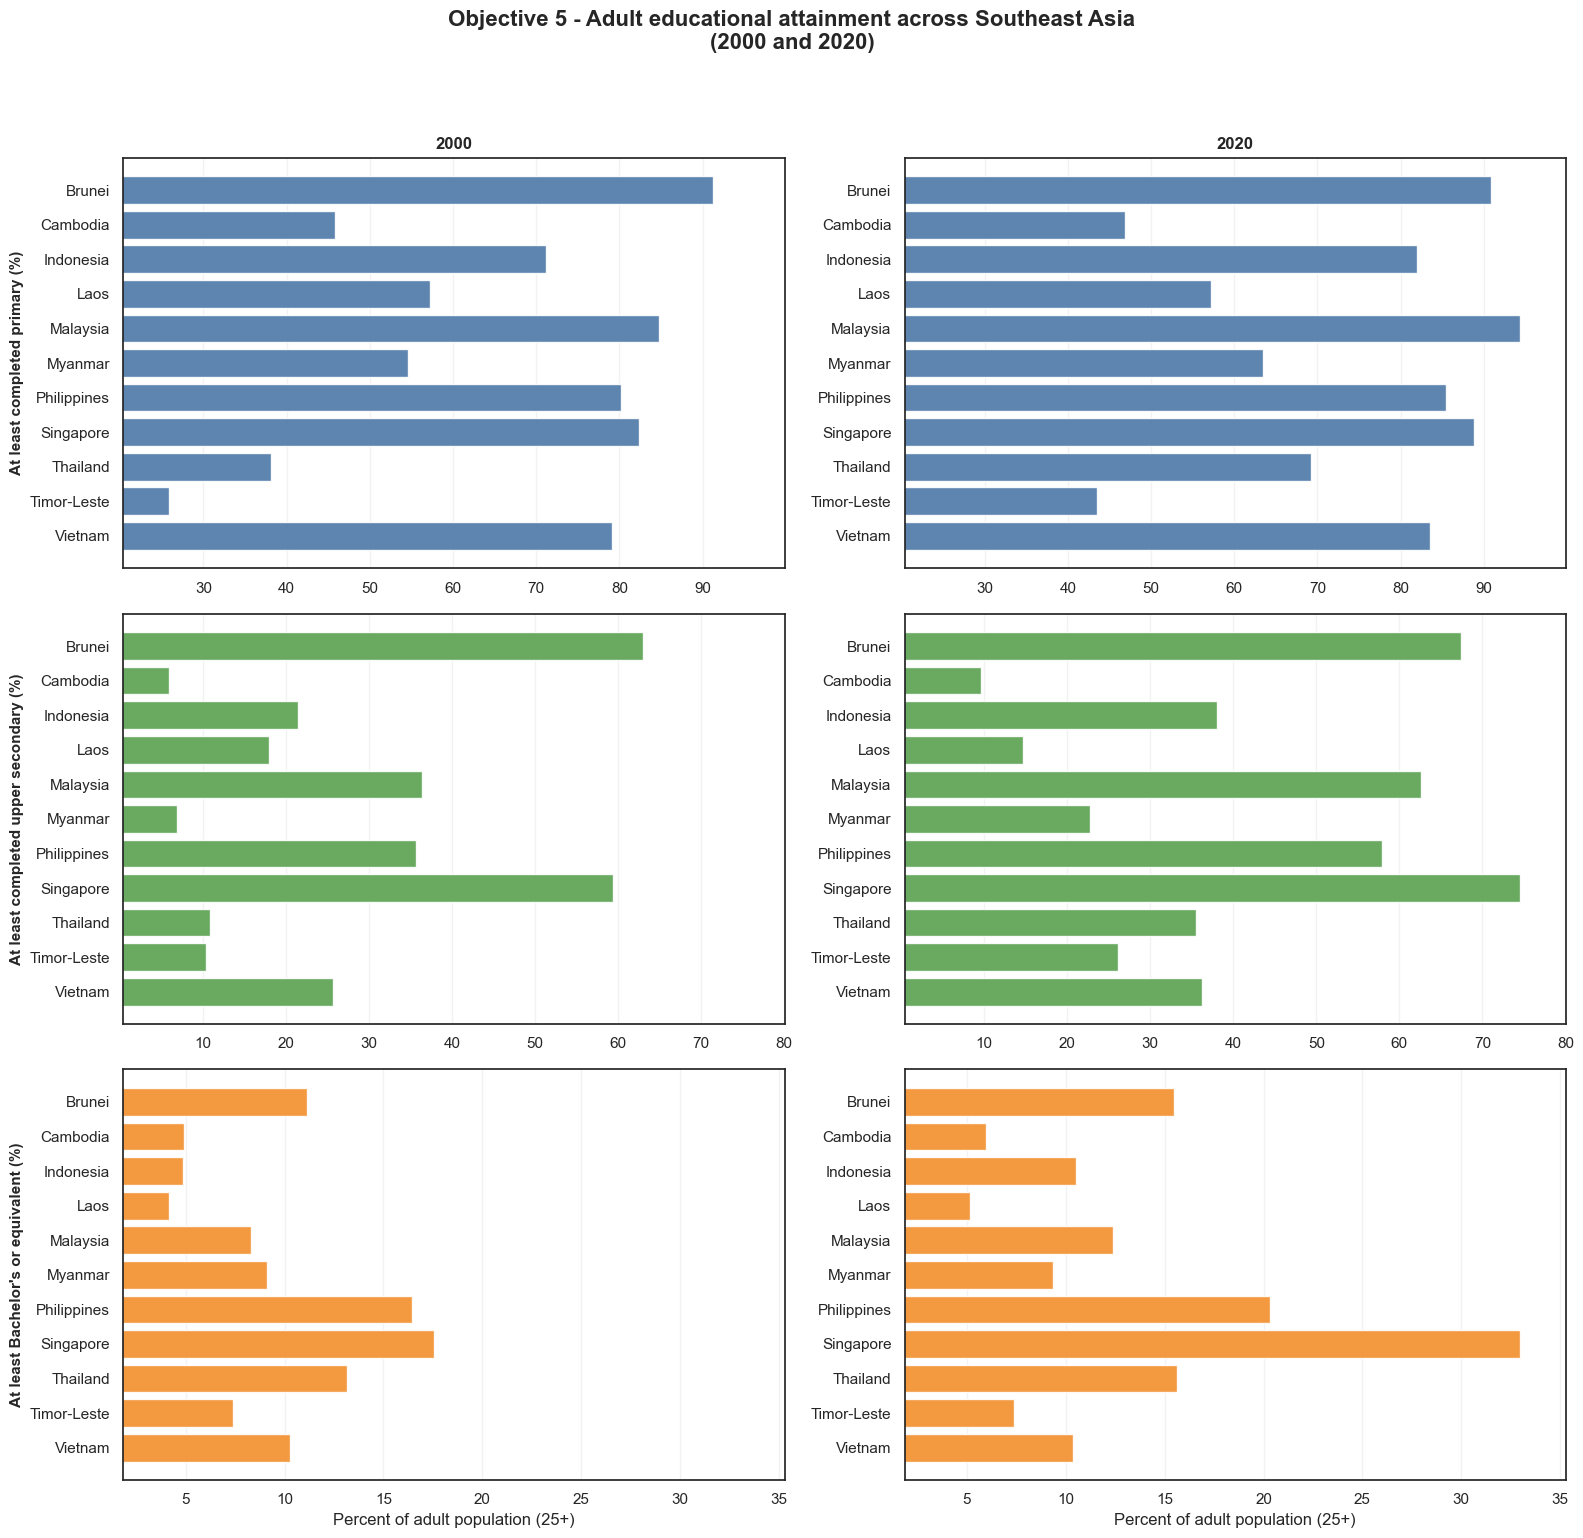

In [20]:
# Chart 1: Horizontal bar charts for overall educational attainment in 2000 and 2020
bar_specs = [
    (OBJ5_COLS["primary_total"], "At least completed primary (%)", "#4C78A8"),
    (OBJ5_COLS["upper_secondary_total"], "At least completed upper secondary (%)", "#59A14F"),
    (OBJ5_COLS["bachelor_total"], "At least Bachelor's or equivalent (%)", "#F28E2B"),
]

x_limits = {}
for col, _, _ in bar_specs:
    vals = obj5_selected[col].dropna()
    x_min = vals.min()
    x_max = vals.max()
    x_pad = (x_max - x_min) * 0.08 if x_max > x_min else 2
    x_limits[col] = (max(0, x_min - x_pad), x_max + x_pad)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.patch.set_facecolor("white")

for row, (col, title, color) in enumerate(bar_specs):
    x_left, x_right = x_limits[col]

    for col_idx, year in enumerate(SELECTED_YEARS):
        ax = axes[row, col_idx]

        plot_df = obj5_selected.loc[
            obj5_selected["Year"].eq(year),
            ["Country", col],
        ].dropna().copy()

        plot_df["Country"] = pd.Categorical(plot_df["Country"], categories=country_order, ordered=True)
        plot_df = plot_df.sort_values("Country")

        ax.barh(plot_df["Country"], plot_df[col], color=color, alpha=0.9)
        ax.invert_yaxis()
        ax.set_xlim(x_left, x_right)

        if row == 0:
            ax.set_title(str(year), fontsize=12, weight="bold")

        if col_idx == 0:
            ax.set_ylabel(title, fontsize=11, weight="bold")
        else:
            ax.set_ylabel("")

        if row == 2:
            ax.set_xlabel("Percent of adult population (25+)")

        ax.grid(axis="x", alpha=0.25)
        ax.set_axisbelow(True)

fig.suptitle(
    "Objective 5 - Adult educational attainment across Southeast Asia\n(2000 and 2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

plt.tight_layout(rect=(0, 0.02, 1, 0.95))
plt.show()



### B. Dumbbell Plot (or Paired Bar Chart)
* **Purpose:** To visualize the gender gap in higher education (Bachelor's, Master's, PhD) for each country.
* **Rationale:** A dumbbell plot plots two distinct data points (male percentage and female percentage) on the same horizontal axis for each country, connected by a line. The length of the connecting line directly represents the size of the gender gap, making disparities immediately obvious and easy to compare across the region.

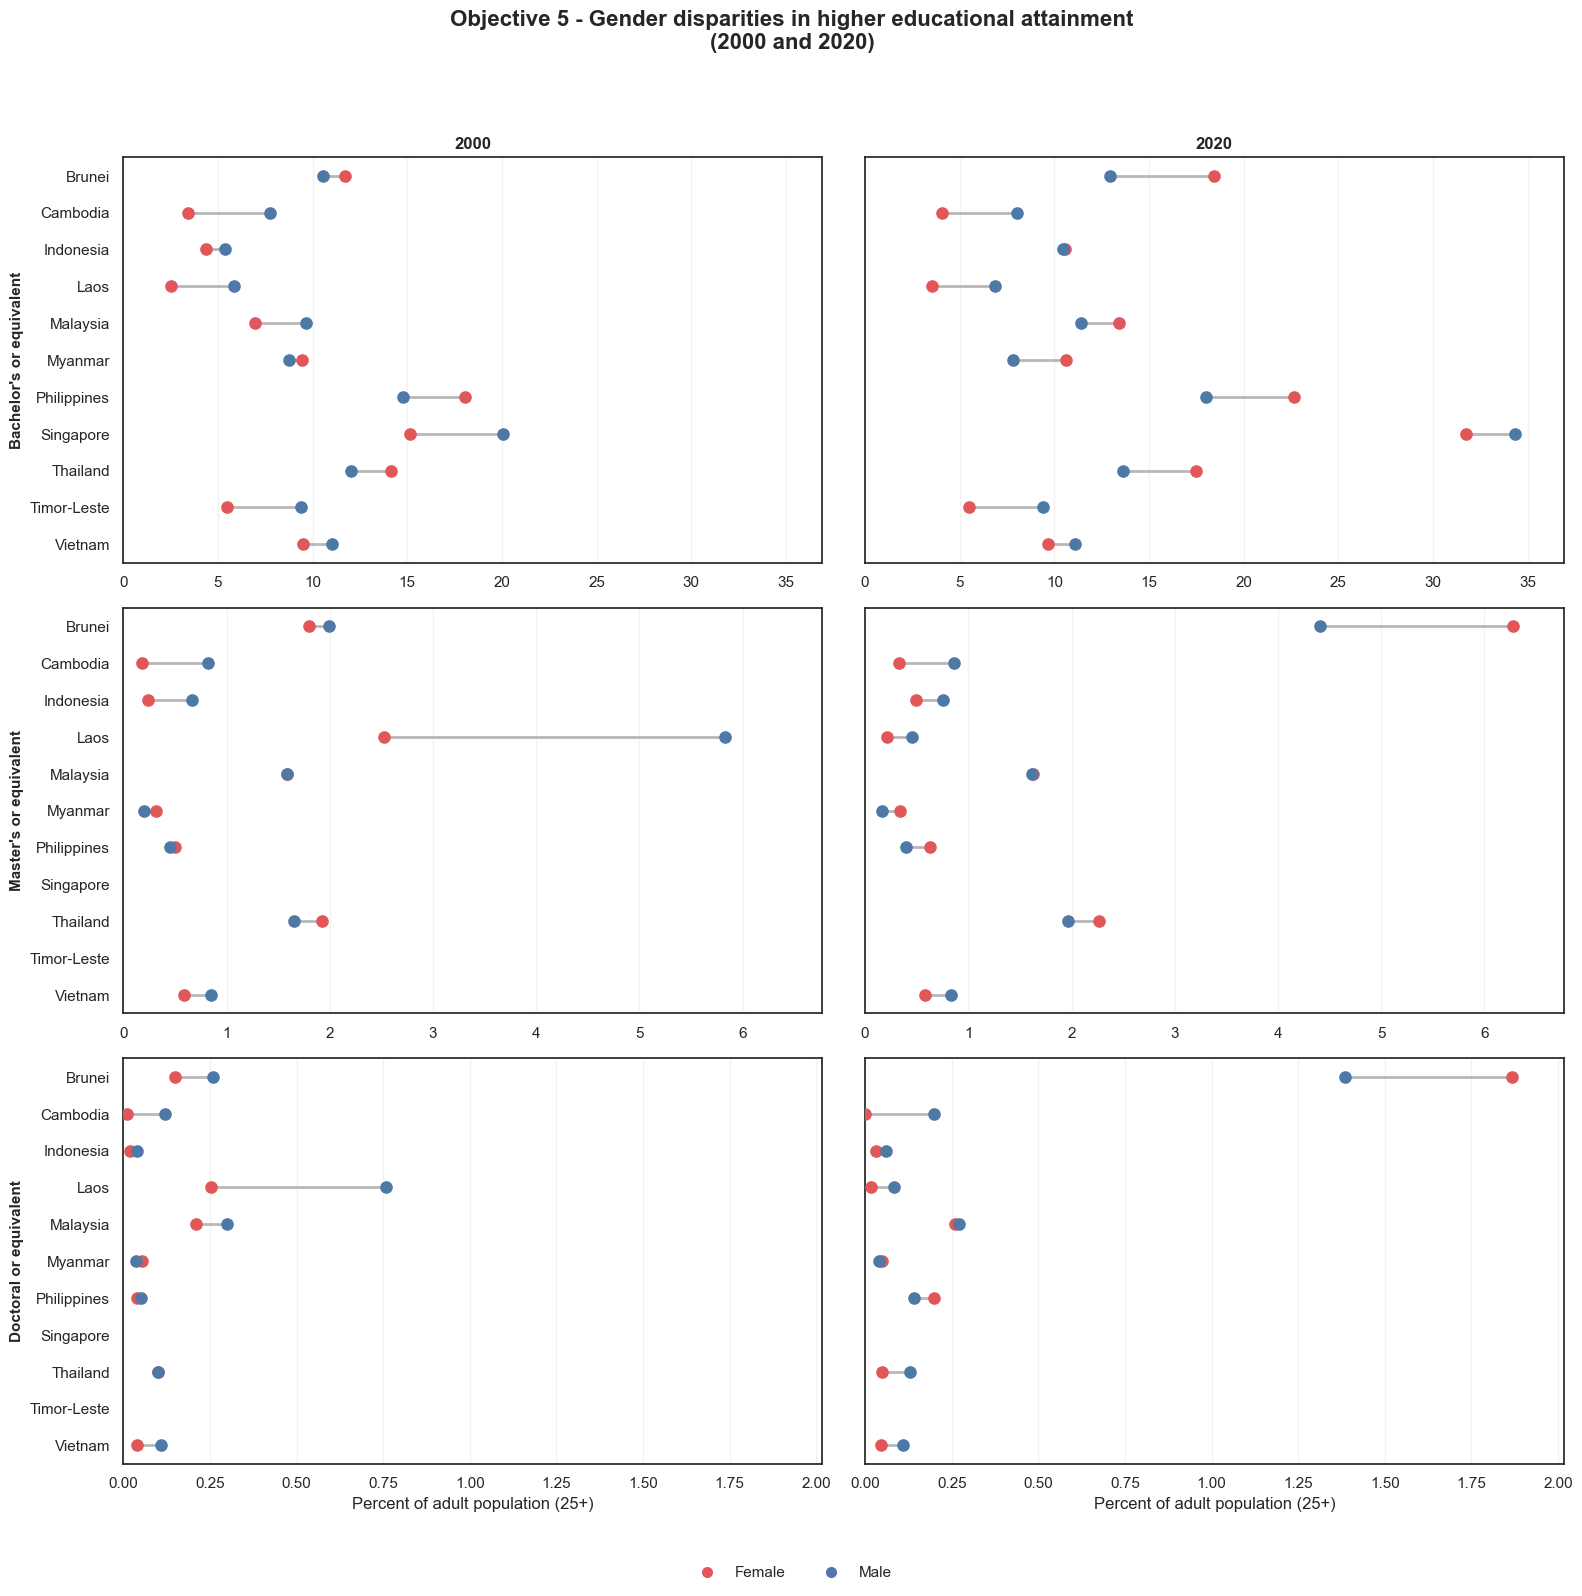

In [21]:
# Chart 2: Dumbbell plots for gender gaps in higher education in 2000 and 2020
dumbbell_specs = [
    (
        OBJ5_COLS["bachelor_female"],
        OBJ5_COLS["bachelor_male"],
        "Bachelor's or equivalent",
    ),
    (
        OBJ5_COLS["master_female"],
        OBJ5_COLS["master_male"],
        "Master's or equivalent",
    ),
    (
        OBJ5_COLS["doctoral_female"],
        OBJ5_COLS["doctoral_male"],
        "Doctoral or equivalent",
    ),
]

female_color = "#E15759"
male_color = "#4E79A7"

x_limits = {}
for female_col, male_col, _ in dumbbell_specs:
    vals = pd.concat(
        [obj5_selected[female_col], obj5_selected[male_col]],
        ignore_index=True,
    ).dropna()
    x_min = vals.min()
    x_max = vals.max()
    x_pad = (x_max - x_min) * 0.08 if x_max > x_min else 1
    x_limits[(female_col, male_col)] = (max(0, x_min - x_pad), x_max + x_pad)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.patch.set_facecolor("white")

for row, (female_col, male_col, title) in enumerate(dumbbell_specs):
    x_left, x_right = x_limits[(female_col, male_col)]

    for col_idx, year in enumerate(SELECTED_YEARS):
        ax = axes[row, col_idx]

        plot_df = obj5_selected.loc[
            obj5_selected["Year"].eq(year),
            ["Country", female_col, male_col],
        ].dropna().copy()

        plot_df["Country"] = pd.Categorical(plot_df["Country"], categories=country_order, ordered=True)
        plot_df = plot_df.sort_values("Country")
        plot_df["y"] = plot_df["Country"].cat.codes

        ax.hlines(
            y=plot_df["y"],
            xmin=plot_df[female_col],
            xmax=plot_df[male_col],
            color="#B0B0B0",
            linewidth=2,
            alpha=0.9,
        )
        ax.scatter(plot_df[female_col], plot_df["y"], color=female_color, s=65, zorder=3)
        ax.scatter(plot_df[male_col], plot_df["y"], color=male_color, s=65, zorder=3)

        ax.set_xlim(x_left, x_right)
        ax.set_ylim(-0.5, len(country_order) - 0.5)
        ax.invert_yaxis()

        if row == 0:
            ax.set_title(str(year), fontsize=12, weight="bold")

        if col_idx == 0:
            ax.set_ylabel(title, fontsize=11, weight="bold")
            ax.set_yticks(range(len(country_order)))
            ax.set_yticklabels(country_order)
        else:
            ax.set_ylabel("")
            ax.set_yticks(range(len(country_order)))
            ax.set_yticklabels([])

        if row == 2:
            ax.set_xlabel("Percent of adult population (25+)")

        ax.grid(axis="x", alpha=0.25)
        ax.set_axisbelow(True)

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=female_color, markersize=9, label="Female"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=male_color, markersize=9, label="Male"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    "Objective 5 - Gender disparities in higher educational attainment\n(2000 and 2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()
